# Freight Rate Prediction Challenge

## Machine Learning Assessment

### Objective

The objective of this project is to develop a regression model that predicts freight rates based on shipment characteristics such as route, distance, equipment type, weight, date, and available market information.

The labeled development dataset is used for data exploration, cleaning, feature engineering, model training, and local validation.

Two regression approaches are evaluated:

- Linear Regression as an interpretable baseline
- Random Forest as a nonlinear alternative

The selected model is retrained on the full development dataset and used to generate the required final predictions.

### Workflow

1. Load and inspect the provided datasets
2. Assess data quality
3. Perform exploratory data analysis
4. Clean and engineer model features
5. Create a chronological validation strategy
6. Train Linear Regression and Random Forest models
7. Compare validation performance
8. Retrain the selected model on all development data
9. Generate final validation predictions
10. Generate the fixed December scenario predictions
11. Validate the required submission files

## 1. Imports and Configuration

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Load the Data

The assessment provides two main datasets:

- `train_test.csv`: labeled development data containing the target variable `posted_rate`.
- `validation.csv`: unlabeled data for which final freight-rate predictions must be generated.

The development dataset will be used for all model development and local validation.

In [ ]:
development_df = pd.read_csv(
 "/content/drive/MyDrive/data/train-test.csv"
)

validation_df = pd.read_csv(
 "/content/drive/MyDrive/data/validation.csv"
)

template_df = pd.read_csv(
 "/content/drive/MyDrive/data/validation-predictions-template.csv"
)

december_df = pd.read_csv(
  "/content/drive/MyDrive/data/december-chart-inputs.csv"
)

In [ ]:
print("Development data:", development_df.shape)
print("Final validation:", validation_df.shape)
print("Prediction template:", template_df.shape)
print("December scenario:", december_df.shape)

Development data: (48000, 14)
Final validation: (12000, 13)
Prediction template: (12000, 2)
December scenario: (31, 7)


## 3. Dataset Structure

Before modifying the data, I verify that the expected target and identifier columns are present and inspect the general structure of the development dataset.

In [ ]:
assert "posted_rate" in development_df.columns
assert "posted_rate" not in validation_df.columns

assert "load_id" in development_df.columns
assert "load_id" in validation_df.columns

print("Development columns:")
print(development_df.columns.tolist())

print("\nValidation columns:")
print(validation_df.columns.tolist())

Development columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

Validation columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']


In [ ]:
development_df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09,-76.79,38.17,-72.75,274.30,Dry Van,"30,658.00",2025-01-01,0.96,2.40,645.41
1,TR-000002,Richmond,Philadelphia,38.09,-76.79,39.22,-72.97,280.50,Reefer,"17,555.00",2025-01-01,0.98,2.43,679.97
2,TR-000003,Philadelphia,Green Bay,39.22,-72.97,44.30,-87.53,967.80,Dry Van,"31,721.00",2025-01-01,1.01,1.84,"1,802.54"
3,TR-000004,Hartford,Atlanta,39.55,-72.18,34.85,-86.29,965.40,Dry Van,"32,333.00",2025-01-01,0.95,1.88,"1,827.28"
4,TR-000005,Dallas,Nashville,31.83,-94.38,35.29,-88.09,541.90,Reefer,"35,183.00",2025-01-01,0.98,2.56,"1,380.28"


In [ ]:
validation_df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50,-92.65,31.80,-88.25,331.40,Flatbed,"19,958.00",2025-11-01,0.90,1.86
1,TE-000002,Savannah,Los Angeles,33.61,-82.30,28.57,-116.70,"2,406.20",Reefer,"34,114.00",2025-11-01,0.93,1.86
2,TE-000003,San Francisco,Raleigh,35.20,-121.70,35.37,-77.48,"2,846.60",Dry Van,"33,435.00",2025-11-01,0.88,1.95
3,TE-000004,Dayton,Los Angeles,39.87,-85.63,28.57,-116.70,"2,261.60",Dry Van,"25,392.00",2025-11-01,0.89,2.15
4,TE-000005,Memphis,San Antonio,35.57,-89.53,29.51,-98.40,800.40,Flatbed,NaN,2025-11-01,0.88,2.23


In [ ]:
development_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


### Initial Observations

The target variable is `posted_rate`, making this a supervised regression problem.

`load_id` is an identifier rather than a predictive feature and will therefore not be used for model training.

The dataset contains a mixture of numerical, categorical, geographical, and temporal variables, which requires different preprocessing strategies.

## 4. Data Quality Assessment

Before modeling, the datasets are checked for missing observations, duplicate records, invalid numerical values, and other potential data-quality issues.

The goal is to identify problems before deciding how they should be handled during preprocessing.

### 4.1 Missing Values

In [ ]:
def missing_summary(frame):
    summary = frame.isna().sum().to_frame(
        "missing_count"
    )

    summary["missing_percent"] = (
        summary["missing_count"]
        / len(frame)
        * 100
    )

    return (
        summary[
            summary["missing_count"] > 0
        ]
        .sort_values(
            "missing_count",
            ascending=False
        )
    )

In [ ]:
missing_summary(development_df)

,missing_count,missing_percent
market_index,374,0.78
weight,300,0.62


In [ ]:
missing_summary(validation_df)

,missing_count,missing_percent
market_index,249,2.08
weight,165,1.38


### Missing Values

Missing observations occur primarily in `weight` and `market_index`.

The affected rows are retained because the missing proportions are relatively small and predictions are required for every final validation load.

Missing numerical values will initially be handled through the model preprocessing pipeline. Imputation statistics will be learned from the training data rather than calculated from the local validation set, reducing the risk of data leakage.

A missing-value indicator will also be retained for selected variables so that the model can distinguish imputed observations from originally observed values.

### 4.2 Duplicates

In [ ]:
print(
    "Duplicate rows:",
    development_df.duplicated().sum()
)

print(
    "Duplicate development IDs:",
    development_df["load_id"].duplicated().sum()
)

print(
    "Duplicate validation IDs:",
    validation_df["load_id"].duplicated().sum()
)

Duplicate rows: 0
Duplicate development IDs: 0
Duplicate validation IDs: 0


### 4.3 Invalid Numerical Values

In [ ]:
print(
    "Negative distance values:",
    (development_df["distance"] < 0).sum()
)

print(
    "Negative weight values:",
    (development_df["weight"] < 0).sum()
)

print(
    "Non-positive posted rates:",
    (development_df["posted_rate"] <= 0).sum()
)

Negative distance values: 0
Negative weight values: 292
Non-positive posted rates: 0


In [ ]:
development_df.loc[
    development_df["weight"] < 0,
    [
        "load_id",
        "weight",
        "distance",
        "equipment",
        "posted_rate"
    ]
].head()

,load_id,weight,distance,equipment,posted_rate
68,TR-000069,"-36,559.00","1,334.20",Reefer,"2,831.27"
204,TR-000205,"-26,670.00",496.20,Dry Van,"1,046.92"
206,TR-000207,"-20,003.00",411.30,Reefer,959.15
225,TR-000226,"-23,981.00","1,317.40",Reefer,"2,836.00"
376,TR-000377,"-41,397.00","1,331.10",Dry Van,"2,522.54"


In [ ]:
print(
    "Validation negative weights:",
    (validation_df["weight"] < 0).sum()
)

Validation negative weights: 145


### Invalid Weight Values

The development data contains negative freight-weight values.

Because physical shipment weight cannot be negative, these records are treated as a sign-related data-quality issue rather than valid negative measurements.

The absolute magnitude of the recorded weight will be retained rather than removing the complete load record.

## 5. Exploratory Data Analysis

The exploratory analysis focuses on relationships that are relevant to freight-rate prediction.

The main questions are:

- How is the target distributed?
- How strongly does distance relate to freight rate?
- Do rates differ by equipment type?
- Do rates change over time?
- Which numerical variables show the strongest linear relationships with the target?

### 5.1 Target Distribution

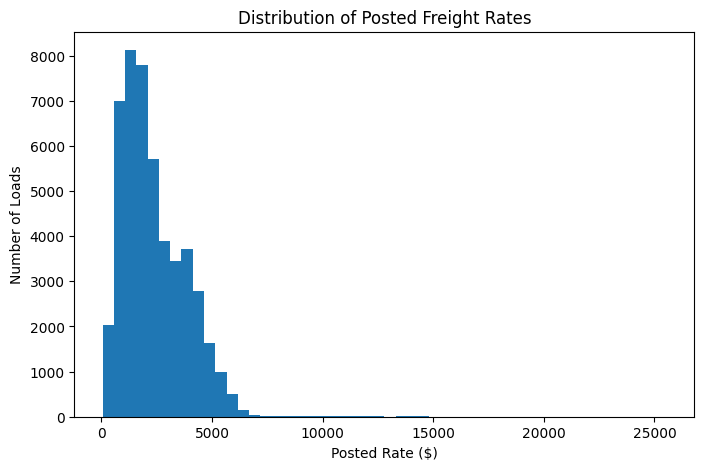

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    development_df["posted_rate"],
    bins=50
)

plt.title("Distribution of Posted Freight Rates")
plt.xlabel("Posted Rate ($)")
plt.ylabel("Number of Loads")

plt.show()

The distribution of `posted_rate` is right-skewed. Most freight rates are concentrated in the lower price range, while a relatively small number of loads have much higher rates.

These high-value observations may represent legitimate expensive shipments rather than data errors, so they are not removed automatically.

Because large prediction errors can strongly affect squared-error metrics, both MAE and RMSE will be considered during model evaluation.

### 5.2 Distance vs Rate

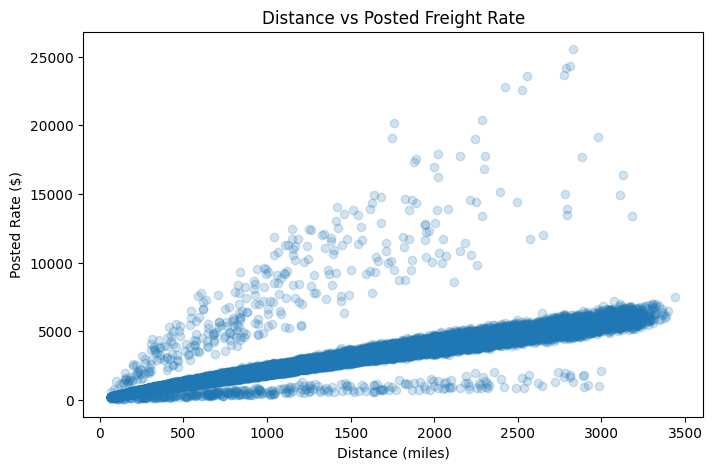

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    development_df["distance"],
    development_df["posted_rate"],
    alpha=0.20
)

plt.title("Distance vs Posted Freight Rate")
plt.xlabel("Distance (miles)")
plt.ylabel("Posted Rate ($)")

plt.show()

In [ ]:
distance_corr = development_df[
    "distance"
].corr(
    development_df["posted_rate"]
)

print(
    f"Distance correlation: "
    f"{distance_corr:.3f}"
)

Distance correlation: 0.909


### Distance and Freight Rate

Distance shows a strong positive relationship with posted freight rate.

Longer shipments generally have higher rates, making distance an important predictive feature.

However, the scatter plot also shows substantial variation around the main relationship, suggesting that additional shipment and market characteristics contribute to freight pricing.

### 5.3 Equipment Type

In [ ]:
equipment_summary = (
    development_df
    .groupby("equipment")["posted_rate"]
    .agg(["count", "mean", "median"])
    .sort_values(
        "mean",
        ascending=False
    )
)

equipment_summary

,count,mean,median
equipment,,,
Reefer,12045,"2,553.64","2,196.67"
Flatbed,8753,"2,445.09","2,076.81"
Dry Van,27202,"2,271.55","1,953.04"


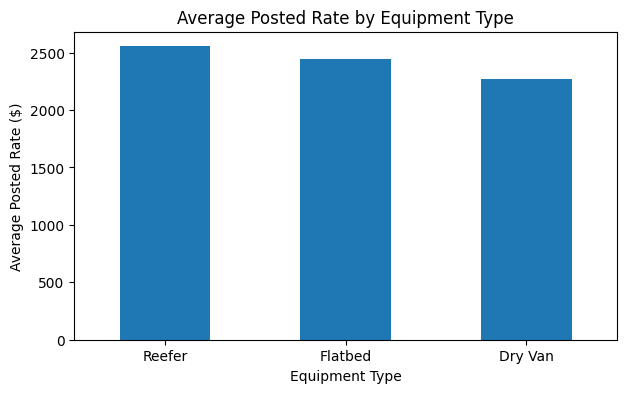

In [ ]:
equipment_summary["mean"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Average Posted Rate by Equipment Type")
plt.xlabel("Equipment Type")
plt.ylabel("Average Posted Rate ($)")
plt.xticks(rotation=0)

plt.show()

### Equipment Type and Freight Rate

Average freight rates differ across equipment categories, suggesting that equipment type contains useful predictive information.

These differences are interpreted as associations rather than direct causal effects because route distance, load characteristics, and market conditions may also differ across equipment groups.

### 5.4 Temporal Trend

In [ ]:
development_df["date"] = pd.to_datetime(
    development_df["date"],
    errors="coerce"
)

validation_df["date"] = pd.to_datetime(
    validation_df["date"],
    errors="coerce"
)

In [ ]:
print(
    "Development period:",
    development_df["date"].min().date(),
    "to",
    development_df["date"].max().date()
)

print(
    "Final validation period:",
    validation_df["date"].min().date(),
    "to",
    validation_df["date"].max().date()
)

Development period: 2025-01-01 to 2025-10-31
Final validation period: 2025-11-01 to 2025-12-31


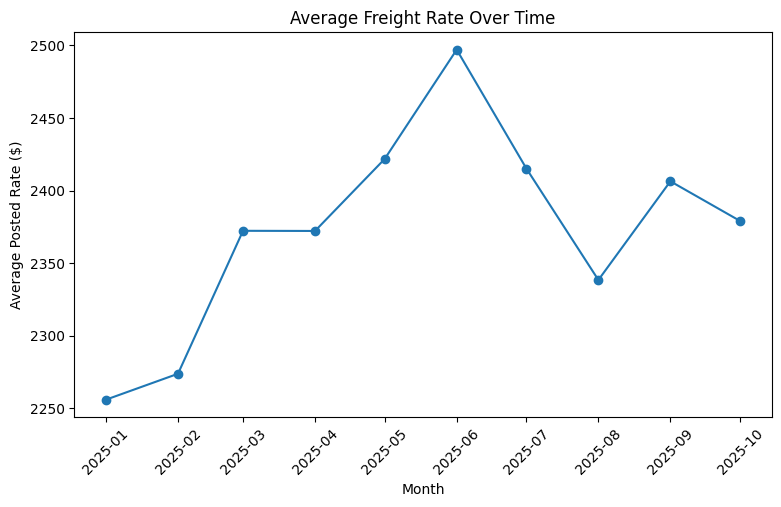

In [ ]:
monthly_rate = (
    development_df
    .set_index("date")
    .resample("MS")["posted_rate"]
    .mean()
)

plt.figure(figsize=(9, 5))

plt.plot(
    monthly_rate.index,
    monthly_rate.values,
    marker="o"
)

plt.title("Average Freight Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Average Posted Rate ($)")
plt.xticks(rotation=45)

plt.show()

### Freight Rates Over Time

Average freight rates vary during the development period rather than remaining constant.

This indicates temporal variation in freight pricing and supports retaining date-related information as model features.

Because the final prediction period occurs chronologically after the development data, local validation should also preserve this chronological relationship.

### 5.5 Numerical Correlations

In [ ]:
correlation_features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

(
    development_df[
        correlation_features
    ]
    .corr()["posted_rate"]
    .sort_values(ascending=False)
)

,posted_rate
posted_rate,1.00
distance,0.91
weight,0.03
market_index,0.03
quote_signal,-0.04


### Numerical Feature Correlations

`distance` has by far the strongest individual linear relationship with the target.

`weight`, `market_index`, and `quote_signal` show weak individual linear correlations with `posted_rate`.

However, low pairwise correlation does not necessarily mean that a feature is uninformative. These variables may contribute through nonlinear relationships or interactions with other shipment characteristics.

For this reason, they will initially be retained and evaluated through model validation rather than removed based only on correlation.

## 6. EDA Summary and Modeling Decisions

The exploratory analysis leads to the following modeling decisions:

- The target is continuous, so the task is formulated as a regression problem.
- `load_id` is an identifier and will not be used as a predictive feature.
- Distance is a strong predictor of freight rate.
- Equipment type contains useful categorical information.
- Freight rates vary over time, so temporal features will be included.
- Weakly correlated numerical variables will initially be retained because they may contribute through interactions or nonlinear relationships.
- Negative freight weights will be corrected using their absolute magnitude.
- Missing numerical values will be handled inside the preprocessing pipeline.
- Missing-value indicators will be included for `weight` and `market_index`.
- A chronological holdout will be used because the final prediction set occurs after the development data.
- Linear Regression will be used as an interpretable baseline.
- Random Forest will be evaluated as a nonlinear alternative.

## 7. Data Cleaning and Feature Engineering

Data preparation is implemented through a reusable function so that the same transformations are applied consistently to the development, validation, and December datasets.

The transformations include:

- Correcting negative weight values
- Converting dates to datetime format
- Creating missing-value indicators
- Extracting calendar-based features
- Creating missing columns when a scenario does not provide all model inputs

In [ ]:
def prepare_features(frame):
    data = frame.copy()

    # Convert date
    data["date"] = pd.to_datetime(
        data["date"],
        errors="coerce"
    )

    # Correct invalid negative weights
    data["weight"] = data["weight"].abs()

    # Columns available in development/validation
    # but not necessarily in the December scenario
    optional_numeric_columns = [
        "pickup_lat",
        "pickup_lon",
        "delivery_lat",
        "delivery_lon",
        "market_index",
        "quote_signal"
    ]

    for column in optional_numeric_columns:
        if column not in data.columns:
            data[column] = np.nan

    # Missing-value indicators
    data["weight_missing"] = (
        data["weight"]
        .isna()
        .astype(int)
    )

    data["market_index_missing"] = (
        data["market_index"]
        .isna()
        .astype(int)
    )

    # Date features
    data["month"] = data["date"].dt.month
    data["day_of_week"] = (
        data["date"].dt.dayofweek
    )
    data["day_of_year"] = (
        data["date"].dt.dayofyear
    )

    return data

In [ ]:
development_model_df = prepare_features(
    development_df
)

validation_model_df = prepare_features(
    validation_df
)

december_model_df = prepare_features(
    december_df
)

### Missing-Value Indicators

A median-imputed value is not identical to an originally observed value.

For this reason, binary indicators are created for `weight` and `market_index`. These indicators allow the model to determine whether the original feature was missing before imputation.

The actual imputation values are still learned only from the model-training data through the preprocessing pipeline.

### December Scenario Compatibility

The fixed December scenario does not provide every numerical feature available in the development dataset.

To keep the prediction workflow consistent, unavailable numerical features are represented as missing values. The fitted preprocessing pipeline then handles these values using statistics learned from the development training data.

This allows the same trained modeling pipeline to be applied to both the final validation set and the required December scenario.

## 8. Define Model Features

In [ ]:
TARGET = "posted_rate"

numeric_features = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day_of_week",
    "day_of_year",
    "weight_missing",
    "market_index_missing"
]

categorical_features = [
    "pickup",
    "delivery",
    "equipment"
]

model_features = (
    numeric_features
    + categorical_features
)

## 9. Chronological Validation Strategy

The final validation data occurs after the labeled development data.

A conventional random train/test split would mix earlier and later observations across both subsets and would not closely represent the final prediction setting.

Therefore, the development data is split chronologically:

- Training period: January through September 2025
- Local validation period: October 2025

This simulates training on historical data and evaluating performance on a future period.

In [ ]:
split_date = pd.Timestamp(
    "2025-10-01"
)

train_df = development_model_df[
    development_model_df["date"] < split_date
].copy()

local_val_df = development_model_df[
    development_model_df["date"] >= split_date
].copy()

In [ ]:
print(
    "Training:",
    train_df["date"].min().date(),
    "to",
    train_df["date"].max().date()
)

print(
    "Local validation:",
    local_val_df["date"].min().date(),
    "to",
    local_val_df["date"].max().date()
)

print(
    "\nTraining rows:",
    len(train_df)
)

print(
    "Validation rows:",
    len(local_val_df)
)

Training: 2025-01-01 to 2025-09-30
Local validation: 2025-10-01 to 2025-10-31

Training rows: 43147
Validation rows: 4853


In [ ]:
X_train = train_df[model_features]
y_train = train_df[TARGET]

X_val = local_val_df[model_features]
y_val = local_val_df[TARGET]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (43147, 16)
X_val: (4853, 16)


## 10. Preprocessing

Numerical and categorical variables require different preprocessing strategies.

For Linear Regression:

- Missing numerical values are imputed using the median
- Numerical variables are standardized
- Missing categorical values are filled using the most frequent category
- Categorical features are one-hot encoded

The preprocessing steps are included inside a pipeline so that all fitted statistics are learned only from the training data.

In [ ]:
linear_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            linear_numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

## 11. Evaluation Function

In [ ]:
def evaluate_regression(
    model_name,
    y_true,
    y_pred
):
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    results = {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    print(model_name)
    print(f"MAE : ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R²  : {r2:.4f}")

    return results

## 12. Linear Regression Baseline

Linear Regression is used as the first model because the exploratory analysis showed a strong approximately linear relationship between distance and freight rate.

It provides an interpretable baseline against which the nonlinear Random Forest model can be compared.

In [ ]:
linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

In [ ]:
linear_model.fit(
    X_train,
    y_train
)

linear_predictions = (
    linear_model.predict(X_val)
)

In [97]:
# Training predictions
linear_train_predictions = linear_model.predict(X_train)

# Validation predictions
linear_val_predictions = linear_model.predict(X_val)

In [98]:
def get_regression_metrics(
    model_name,
    dataset_name,
    y_true,
    y_pred
):
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [99]:
linear_train_results = get_regression_metrics(
    "Linear Regression",
    "Train",
    y_train,
    linear_train_predictions
)

linear_val_results = get_regression_metrics(
    "Linear Regression",
    "Validation",
    y_val,
    linear_val_predictions
)

In [ ]:
linear_results = evaluate_regression(
    "Linear Regression",
    y_val,
    linear_predictions
)

Linear Regression
MAE : $141.87
RMSE: $651.27
R²  : 0.8185


## 13. Random Forest

Random Forest is evaluated as a nonlinear alternative.

Unlike Linear Regression, tree-based models can capture nonlinear relationships and interactions between shipment characteristics without requiring those relationships to be explicitly specified.

In [ ]:
rf_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            rf_numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [ ]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            rf_preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = (
    random_forest_model.predict(X_val)
)

In [101]:
rf_train_predictions = random_forest_model.predict(
    X_train
)

rf_val_predictions = random_forest_model.predict(
    X_val
)

In [102]:
rf_train_results = get_regression_metrics(
    "Random Forest",
    "Train",
    y_train,
    rf_train_predictions
)

rf_val_results = get_regression_metrics(
    "Random Forest",
    "Validation",
    y_val,
    rf_val_predictions
)

In [ ]:
rf_results = evaluate_regression(
    "Random Forest",
    y_val,
    rf_predictions
)

Random Forest
MAE : $243.59
RMSE: $759.31
R²  : 0.7532


## 14. Model Comparison

In [ ]:
model_comparison = pd.DataFrame(
    [
        linear_results,
        rf_results
    ]
)

model_comparison.sort_values(
    "MAE"
)

,Model,MAE,RMSE,R2
0,Linear Regression,141.87,651.27,0.82
1,Random Forest,243.59,759.31,0.75


In [103]:
train_validation_comparison = pd.DataFrame(
    [
        linear_train_results,
        linear_val_results,
        rf_train_results,
        rf_val_results
    ]
)

train_validation_comparison

,Model,Dataset,MAE,RMSE,R2
0,Linear Regression,Train,138.62,591.47,0.84
1,Linear Regression,Validation,141.87,651.27,0.82
2,Random Forest,Train,48.04,227.99,0.98
3,Random Forest,Validation,243.59,759.31,0.75


### Training vs Validation Performance

Linear Regression shows similar performance on the training and chronological validation sets.

Its MAE increases only slightly from 138.62 on the training data to 141.87 on the validation data, while R² decreases from 0.84 to 0.82. This small performance gap suggests that the model generalizes well to unseen future observations.

In contrast, Random Forest shows a substantial difference between training and validation performance. It achieves an MAE of 48.04 and an R² of 0.98 on the training data, but validation performance declines to an MAE of 243.59 and an R² of 0.75.

This large train-validation gap indicates overfitting. The Random Forest fits the historical training observations very closely but does not generalize as effectively to the future October holdout.

For this reason, Linear Regression is preferred for the final prediction task.

### Model Selection

Linear Regression outperformed Random Forest on all three validation metrics.

- Linear Regression achieved a lower MAE, indicating smaller typical prediction errors.
- It also achieved a lower RMSE, indicating better performance when larger errors are given more weight.
- Its higher R² indicates that it explained more of the variation in October freight rates.

Because the models were evaluated on the same chronological holdout, Linear Regression is currently the preferred model for this task.

The result also suggests that much of the predictive structure in the available features can be captured effectively by an additive linear model. The Random Forest may also be less effective when generalizing to a future time period outside the dates used for training.

## 15. Error Analysis

Before finalizing the model, I examine the Linear Regression prediction errors on the chronological validation set.

The goal is to identify whether poor predictions are concentrated in particular types of loads or whether a small number of extreme observations are driving the RMSE.

In [ ]:
linear_error_df = local_val_df[
    [
        "load_id",
        "date",
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "market_index",
        "quote_signal",
        "posted_rate"
    ]
].copy()

linear_error_df["predicted_rate"] = (
    linear_predictions
)

linear_error_df["residual"] = (
    linear_error_df["posted_rate"]
    - linear_error_df["predicted_rate"]
)

linear_error_df["absolute_error"] = (
    linear_error_df["residual"].abs()
)

In [ ]:
linear_error_df.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,load_id,date,pickup,delivery,distance,equipment,weight,market_index,quote_signal,posted_rate,predicted_rate,residual,absolute_error
43539,TR-043540,2025-10-03,Milwaukee,Bakersfield,"1,893.00",Dry Van,"30,760.00",1.08,2.23,"17,514.11","3,683.68","13,830.43","13,830.43"
46213,TR-046214,2025-10-20,Columbia,Tucson,"2,023.40",Flatbed,"34,710.00",0.90,2.07,"17,893.17","4,128.13","13,765.04","13,765.04"
47298,TR-047299,2025-10-27,Boston,Bakersfield,"2,979.10",Reefer,"30,585.00",0.87,2.09,"19,110.30","5,982.40","13,127.90","13,127.90"
46516,TR-046517,2025-10-22,Toledo,Albuquerque,"1,684.30",Reefer,"31,536.00",0.99,2.06,"14,784.38","3,601.06","11,183.32","11,183.32"
46366,TR-046367,2025-10-21,Bakersfield,Columbia,"2,251.90",Dry Van,"40,729.00",0.95,2.19,"14,403.14","4,439.22","9,963.92","9,963.92"
47536,TR-047537,2025-10-29,Los Angeles,Richmond,"2,782.40",Dry Van,"25,730.00",1.03,2.39,"15,003.55","5,322.92","9,680.63","9,680.63"
44267,TR-044268,2025-10-08,Albany,Albuquerque,"2,492.60",Dry Van,"25,513.00",1.06,2.39,"14,425.42","4,779.92","9,645.50","9,645.50"
43302,TR-043303,2025-10-01,Atlanta,Phoenix,"2,083.10",Reefer,"40,335.00",0.91,1.95,"13,894.55","4,368.16","9,526.39","9,526.39"
43384,TR-043385,2025-10-02,Lexington,Lubbock,"1,187.00",Dry Van,"25,359.00",0.96,2.17,"11,696.44","2,430.11","9,266.33","9,266.33"
47586,TR-047587,2025-10-29,Corpus Christi,Las Vegas,"1,383.30",Flatbed,"18,645.00",1.02,2.02,"11,596.28","2,940.59","8,655.69","8,655.69"


## Actual vs Predicted

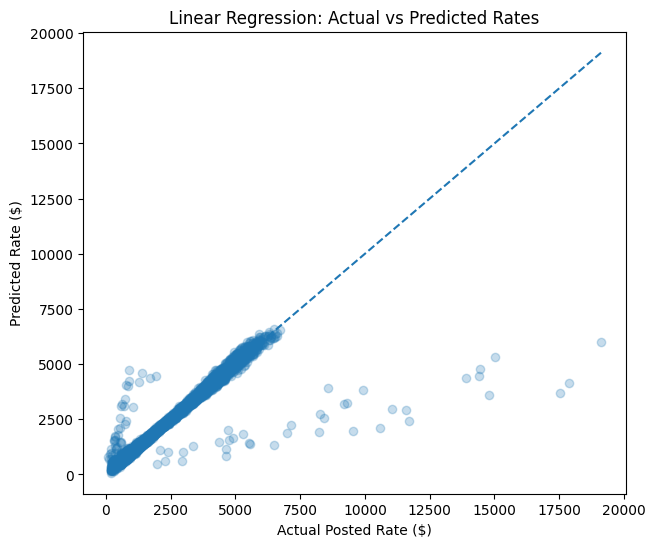

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_val,
    linear_predictions,
    alpha=0.25
)

minimum = min(
    y_val.min(),
    linear_predictions.min()
)

maximum = max(
    y_val.max(),
    linear_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title(
    "Linear Regression: Actual vs Predicted Rates"
)

plt.xlabel("Actual Posted Rate ($)")
plt.ylabel("Predicted Rate ($)")

plt.show()

### Residual Distribution

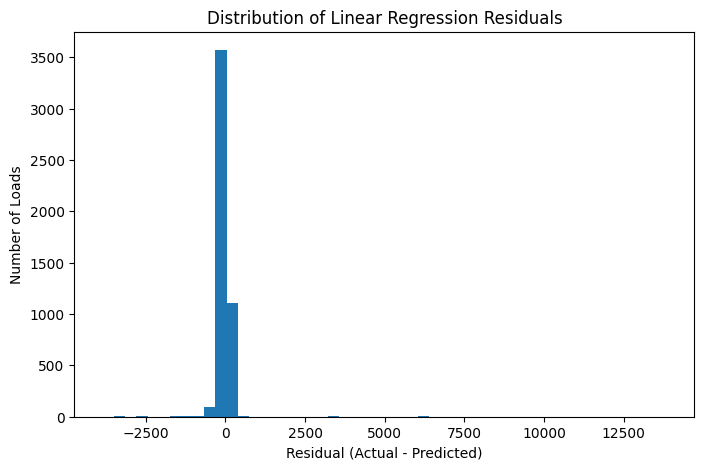

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    linear_error_df["residual"],
    bins=50
)

plt.title(
    "Distribution of Linear Regression Residuals"
)

plt.xlabel(
    "Residual (Actual - Predicted)"
)

plt.ylabel("Number of Loads")

plt.show()

### Error by Equipment

In [ ]:
error_by_equipment = (
    linear_error_df
    .groupby("equipment")
    .agg(
        loads=("load_id", "count"),
        mae=("absolute_error", "mean")
    )
    .sort_values("mae")
)

error_by_equipment

,loads,mae
equipment,,
Dry Van,2745,132.78
Flatbed,918,132.93
Reefer,1190,169.74


### 15.4 Diagnostic Summary

Linear Regression clearly outperformed Random Forest on the chronological October holdout.

The Linear Regression model achieved lower MAE and RMSE and a higher R², indicating better generalization to the future validation period.

Error analysis showed that most predictions are close to the actual freight rates. However, a small number of high-rate loads are substantially underpredicted, producing a long positive residual tail and increasing RMSE.

Prediction errors are similar for Dry Van and Flatbed loads, while Reefer loads show somewhat higher MAE. This difference is not large enough to justify separate models by equipment type.

The extreme high-rate observations are retained because there is insufficient evidence to classify them as erroneous data.

## 16. Interaction Feature Experiment

The baseline Linear Regression model captures the main relationship between shipment characteristics and freight rates well.

To test whether market signals modify the effect of shipment distance, several interaction features are introduced:

- `distance × quote_signal`
- `distance × market_index`
- `distance × quote_signal × market_index`

These features are evaluated using the same chronological October holdout. They will only be retained if they improve out-of-time validation performance.

In [89]:
development_fe_df = development_model_df.copy()

development_fe_df["distance_quote"] = (
    development_fe_df["distance"]
    * development_fe_df["quote_signal"]
)

development_fe_df["distance_market"] = (
    development_fe_df["distance"]
    * development_fe_df["market_index"]
)

development_fe_df["distance_quote_market"] = (
    development_fe_df["distance"]
    * development_fe_df["quote_signal"]
    * development_fe_df["market_index"]
)

In [90]:
interaction_correlations = (
    development_fe_df[
        [
            "distance",
            "distance_quote",
            "distance_market",
            "distance_quote_market",
            "posted_rate"
        ]
    ]
    .corr()["posted_rate"]
    .sort_values(ascending=False)
)

interaction_correlations

,posted_rate
posted_rate,1.00
distance,0.91
distance_quote,0.90
distance_market,0.88
distance_quote_market,0.87


In [91]:
numeric_features_fe = numeric_features + [
    "distance_quote",
    "distance_market",
    "distance_quote_market"
]

model_features_fe = (
    numeric_features_fe
    + categorical_features
)

In [92]:
train_fe_df = development_fe_df[
    development_fe_df["date"] < split_date
].copy()

val_fe_df = development_fe_df[
    development_fe_df["date"] >= split_date
].copy()

X_train_fe = train_fe_df[model_features_fe]
y_train_fe = train_fe_df[TARGET]

X_val_fe = val_fe_df[model_features_fe]
y_val_fe = val_fe_df[TARGET]

In [93]:
linear_preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "num",
            linear_numeric_pipeline,
            numeric_features_fe
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

linear_model_fe = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor_fe
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

In [94]:
linear_model_fe.fit(
    X_train_fe,
    y_train_fe
)

linear_fe_predictions = linear_model_fe.predict(
    X_val_fe
)

In [95]:
linear_fe_results = evaluate_regression(
    "Linear Regression + Interactions",
    y_val_fe,
    linear_fe_predictions
)

Linear Regression + Interactions
MAE : $153.26
RMSE: $655.11
R²  : 0.8163


In [96]:
pd.DataFrame(
    [
        linear_results,
        linear_fe_results,
        rf_results
    ]
).sort_values("MAE")

,Model,MAE,RMSE,R2
0,Linear Regression,141.87,651.27,0.82
1,Linear Regression + Interactions,153.26,655.11,0.82
2,Random Forest,243.59,759.31,0.75


### Interaction Experiment Conclusion

The engineered interaction features did not improve out-of-time validation performance.

The baseline Linear Regression achieved a lower MAE and RMSE than the interaction-based version. Therefore, the additional interaction features were not retained.

The original Linear Regression pipeline remains the selected final model.

## 17. Final Model Training

Linear Regression was selected as the final model because it achieved the best chronological validation performance and showed a small gap between training and validation metrics.

After model selection, the model is retrained using the complete labeled development dataset, including the October observations that were previously reserved for local validation.

Using all available labeled data gives the final model the maximum amount of historical information before generating predictions for November and December.

In [104]:
X_full = development_model_df[model_features]
y_full = development_model_df[TARGET]

print("Final training rows:", len(X_full))
print("Number of features:", len(model_features))

Final training rows: 48000
Number of features: 16


In [105]:
final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

In [106]:
final_model.fit(
    X_full,
    y_full
)

print("Final Linear Regression model trained successfully.")

Final Linear Regression model trained successfully.


## 18. Final Validation Predictions

The final model is applied to all 12,000 loads in `validation.csv`.

The true freight rates for this dataset are hidden by Spotter, so this dataset is used only for final prediction and is not used for model evaluation or model selection.

In [107]:
X_final_validation = validation_model_df[
    model_features
]

print(
    "Final validation rows:",
    len(X_final_validation)
)

Final validation rows: 12000


In [108]:
final_predictions = final_model.predict(
    X_final_validation
)

In [109]:
print(
    "Number of predictions:",
    len(final_predictions)
)

print(
    f"Minimum predicted rate: ${final_predictions.min():,.2f}"
)

print(
    f"Maximum predicted rate: ${final_predictions.max():,.2f}"
)

print(
    "Non-positive predictions:",
    (final_predictions <= 0).sum()
)

print(
    "Invalid predictions:",
    (~np.isfinite(final_predictions)).sum()
)

Number of predictions: 12000
Minimum predicted rate: $111.04
Maximum predicted rate: $6,592.58
Non-positive predictions: 0
Invalid predictions: 0


## 19. Create Final Validation Submission

The final model generated predictions for all 12,000 validation loads.

Before saving the submission, the predictions were checked for missing, infinite, and non-positive values to ensure compatibility with the provided scoring script.

In [110]:
predictions_df = pd.DataFrame({
    "load_id": validation_df["load_id"],
    "predicted_rate": final_predictions
})

submission_df = (
    template_df[["load_id"]]
    .merge(
        predictions_df,
        on="load_id",
        how="left",
        validate="one_to_one"
    )
)

submission_df.head()

,load_id,predicted_rate
0,TE-000001,934.27
1,TE-000002,"4,837.38"
2,TE-000003,"5,412.72"
3,TE-000004,"4,197.90"
4,TE-000005,"1,843.17"


In [111]:
assert list(submission_df.columns) == [
    "load_id",
    "predicted_rate"
]

assert len(submission_df) == 12_000
assert submission_df["load_id"].isna().sum() == 0
assert submission_df["load_id"].duplicated().sum() == 0
assert submission_df["predicted_rate"].isna().sum() == 0
assert np.isfinite(submission_df["predicted_rate"]).all()
assert (submission_df["predicted_rate"] > 0).all()

print("All validation submission checks passed.")

All validation submission checks passed.


In [112]:
submission_df.to_csv(
    "validation_predictions.csv",
    index=False
)

print("Saved: validation_predictions.csv")

Saved: validation_predictions.csv


In [113]:
submission_df.head()

,load_id,predicted_rate
0,TE-000001,934.27
1,TE-000002,"4,837.38"
2,TE-000003,"5,412.72"
3,TE-000004,"4,197.90"
4,TE-000005,"1,843.17"


In [114]:
submission_df.tail()

,load_id,predicted_rate
11995,TE-011996,965.31
11996,TE-011997,"1,663.53"
11997,TE-011998,"1,130.10"
11998,TE-011999,"3,496.35"
11999,TE-012000,891.30


## 20. December Scenario Predictions

The December scenario contains a fixed route from Lexington to Fort Wayne with constant distance, equipment type, and weight, while the date changes across the 31 days of December.

Because the December input file does not include geographical coordinates, the known city coordinates are recovered from the labeled development data using the pickup and delivery city names.

Market-related features that are not supplied in the December scenario remain missing and are handled by the fitted preprocessing pipeline using statistics learned from the development data.

In [115]:
december_model_df = december_df.copy()

december_model_df["date"] = pd.to_datetime(
    december_model_df["date"],
    errors="coerce"
)

In [117]:
pickup_coordinates = (
    development_df[
        ["pickup", "pickup_lat", "pickup_lon"]
    ]
    .drop_duplicates("pickup")
    .set_index("pickup")
)

delivery_coordinates = (
    development_df[
        ["delivery", "delivery_lat", "delivery_lon"]
    ]
    .drop_duplicates("delivery")
    .set_index("delivery")
)

In [118]:
december_model_df["pickup_lat"] = (
    december_model_df["pickup"]
    .map(pickup_coordinates["pickup_lat"])
)

december_model_df["pickup_lon"] = (
    december_model_df["pickup"]
    .map(pickup_coordinates["pickup_lon"])
)

december_model_df["delivery_lat"] = (
    december_model_df["delivery"]
    .map(delivery_coordinates["delivery_lat"])
)

december_model_df["delivery_lon"] = (
    december_model_df["delivery"]
    .map(delivery_coordinates["delivery_lon"])
)

In [119]:
december_model_df[
    [
        "pickup",
        "pickup_lat",
        "pickup_lon",
        "delivery",
        "delivery_lat",
        "delivery_lon"
    ]
].head()

,pickup,pickup_lat,pickup_lon,delivery,delivery_lat,delivery_lon
0,Lexington,36.99,-85.00,Fort Wayne,41.32,-85.36
1,Lexington,36.99,-85.00,Fort Wayne,41.32,-85.36
2,Lexington,36.99,-85.00,Fort Wayne,41.32,-85.36
3,Lexington,36.99,-85.00,Fort Wayne,41.32,-85.36
4,Lexington,36.99,-85.00,Fort Wayne,41.32,-85.36


## 21. Add the Same Features Used by the Model

In [120]:
december_model_df["weight"] = (
    december_model_df["weight"].abs()
)

december_model_df["weight_missing"] = (
    december_model_df["weight"].isna().astype(int)
)

In [121]:
december_model_df["market_index"] = np.nan
december_model_df["quote_signal"] = np.nan

december_model_df["market_index_missing"] = 1

In [122]:
december_model_df["month"] = (
    december_model_df["date"].dt.month
)

december_model_df["day_of_week"] = (
    december_model_df["date"].dt.dayofweek
)

december_model_df["day_of_year"] = (
    december_model_df["date"].dt.dayofyear
)

In [123]:
missing_model_columns = [
    col
    for col in model_features
    if col not in december_model_df.columns
]

print("Missing model columns:", missing_model_columns)

Missing model columns: []


## 22. Generate December Predictions

In [124]:
X_december = december_model_df[
    model_features
]

december_predictions = final_model.predict(
    X_december
)

In [125]:
print(
    "Number of December predictions:",
    len(december_predictions)
)

print(
    f"Minimum December prediction: "
    f"${december_predictions.min():,.2f}"
)

print(
    f"Maximum December prediction: "
    f"${december_predictions.max():,.2f}"
)

print(
    "Non-positive December predictions:",
    (december_predictions <= 0).sum()
)

Number of December predictions: 31
Minimum December prediction: $839.02
Maximum December prediction: $888.63
Non-positive December predictions: 0


## 23. Fill the Required December File

In [126]:
december_output_df = december_df.copy()

december_output_df["predicted_rate"] = (
    december_predictions
)

december_output_df.head()

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,839.02
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,839.13
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,839.24
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,839.35
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,839.47


In [127]:
expected_december_columns = [
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "date",
    "predicted_rate"
]

assert list(december_output_df.columns) == (
    expected_december_columns
)

assert len(december_output_df) == 31

assert (
    december_output_df["predicted_rate"]
    .notna()
    .all()
)

assert np.isfinite(
    december_output_df["predicted_rate"]
).all()

assert (
    december_output_df["predicted_rate"] > 0
).all()

print("All December checks passed.")

All December checks passed.


## 24. Save and Validate Final Outputs

The completed December scenario contains one positive prediction for each day from December 1 through December 31.

Because all shipment characteristics are fixed in this scenario and only the date changes, the resulting predictions provide a view of the temporal behavior of the selected model.

In [128]:
DECEMBER_OUTPUT_PATH = (
    "december_chart_inputs.csv"
)

december_output_df.to_csv(
    DECEMBER_OUTPUT_PATH,
    index=False
)

print(
    f"Saved: {DECEMBER_OUTPUT_PATH}"
)

Saved: december_chart_inputs.csv


In [130]:
from pathlib import Path

validation_path = Path("validation_predictions.csv")
december_path = Path(DECEMBER_OUTPUT_PATH)

print(
    "Validation predictions exists:",
    validation_path.is_file()
)

print(
    "December predictions exists:",
    december_path.is_file()
)

Validation predictions exists: True
December predictions exists: True


## 25. Run the Provided Scorer

In [133]:
from pathlib import Path

print("requirements.txt exists:", Path("requirements.txt").is_file())

requirements.txt exists: True


In [134]:
!python -m pip install -r requirements.txt

In [138]:
from pathlib import Path

print("score.py exists:", Path("score.py").is_file())

score.py exists: True


In [139]:
!python score.py \
    --predictions /content/validation_predictions.csv \
    --december-predictions /content/december_chart_inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


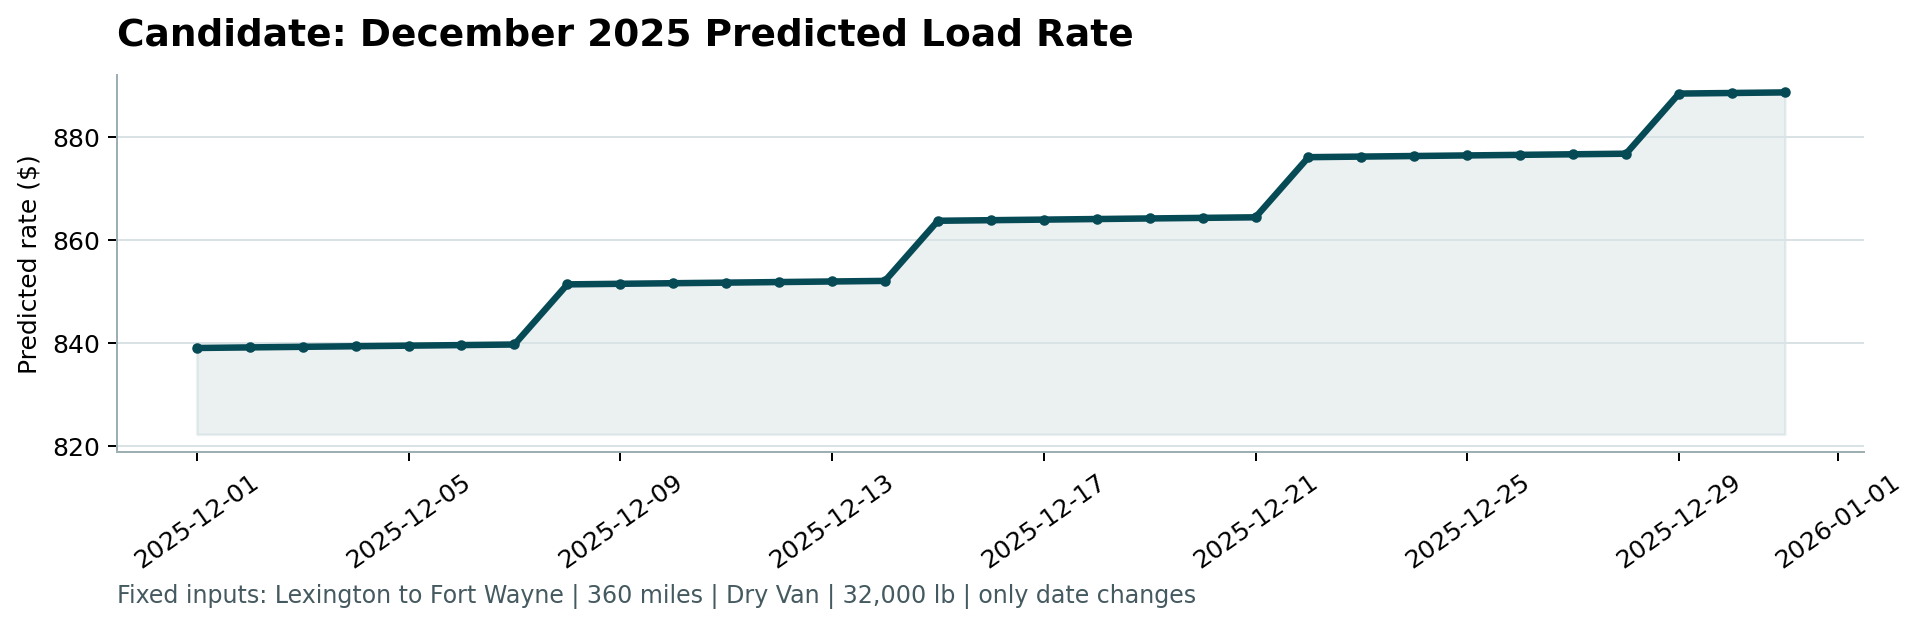

In [140]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/scorer_results/candidate_december.png"
    )
)